# **Modelling Student Academic Success**
## A Knowledge Graph Approach Integrating Socioeconomic, Behavioural, and Educational Factors

## **Dependencies**

This section installs and imports all required libraries for the project, including data handling, graph processing, and machine learning.

- `rdflib` for working with RDF data and ontologies  
- `pyshacl` for validating RDF data using SHACL  
- `pykeen` for knowledge graph embedding and link prediction

In [ ]:
!pip install rdflib
!pip install pyshacl
!pip install pykeen

---

## **Modules**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rdflib as rdf
import kagglehub
import os
import networkx as nx

from kagglehub import KaggleDatasetAdapter
from rdflib import Graph, RDF, RDFS, OWL, Literal, Namespace, XSD, URIRef
from pyshacl import validate
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

ModuleNotFoundError: No module named 'rdflib'

# **Student Alcohol Consumption Dataset**

Download and load the student alcohol consumption datasets from Kaggle.

In [ ]:
path = kagglehub.dataset_download("uciml/student-alcohol-consumption")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/student-alcohol-consumption


In [ ]:
print(os.listdir(path))

['student-mat.csv', 'student-merge.R', 'student-por.csv']


### student-por.csv

Load the Portuguese student dataset into a pandas DataFrame.

In [ ]:
pt_file_path = "student-por.csv"

pt_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/student-alcohol-consumption",
  pt_file_path
)

<ipython-input-5-77949d4e4b9f>:3: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  pt_df = kagglehub.load_dataset(


In [ ]:
pt_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


### student-mat.csv

Load the Math student dataset into a pandas DataFrame.

In [ ]:
mat_file_path = "student-mat.csv"

mat_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/student-alcohol-consumption",
  mat_file_path
)

<ipython-input-7-2ea712d6aa2b>:3: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  mat_df = kagglehub.load_dataset(


In [ ]:
mat_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# **Create an OWL Ontology from the CSV File**

Build an OWL ontology (knowledge graph) from the `student-mat.csv` file. It defines classes, object properties, data properties, and creates individuals for each student and related entities.

In [ ]:
# Create a new graph
g = Graph()

# Define your namespace
STU = Namespace("http://www.example.org/student-performance#")
g.bind("stu", STU)

# Define classes
classes = [
    "Student", "School", "Course", "Parent", "Guardian", "Job", "EducationLevel",
    "AddressType", "StudyHabit", "AlcoholUse", "HealthStatus", "RelationshipStatus", "Grade", "Location"
]

for c in classes:
    g.add((STU[c], RDF.type, OWL.Class))

# Define Object Properties
object_properties = {
    "attends": ("Student", "School"),
    "enrolledIn": ("Student", "Course"),
    "hasParent": ("Student", "Parent"),
    "hasGuardian": ("Student", "Guardian"),
    "hasJob": ("Parent", "Job"),
    "hasEducationLevel": ("Parent", "EducationLevel"),
    "livesAt": ("Student", "AddressType"),
    "hasStudyHabit": ("Student", "StudyHabit"),
    "hasAlcoholUse": ("Student", "AlcoholUse"),
    "hasHealthStatus": ("Student", "HealthStatus"),
    "hasRelationshipStatus": ("Student", "RelationshipStatus"),
    "achievedGrade": ("Student", "Grade")
}

for prop, (domain, range_) in object_properties.items():
    g.add((STU[prop], RDF.type, OWL.ObjectProperty))
    g.add((STU[prop], RDFS.domain, STU[domain]))
    g.add((STU[prop], RDFS.range, STU[range_]))

# Define Data Properties
data_properties = {
    "hasSex": XSD.string,
    "hasAge": XSD.integer,
    "hasAbsences": XSD.integer,
    "G1": XSD.integer,
    "G2": XSD.integer,
    "G3": XSD.integer,
    "hasFreeTime": XSD.integer,
    "goesOut": XSD.integer,
    "wantsHigherEdu": XSD.boolean,
    "hasInternet": XSD.boolean
}

for prop, dtype in data_properties.items():
    g.add((STU[prop], RDF.type, OWL.DatatypeProperty))
    g.add((STU[prop], RDFS.domain, STU.Student))
    g.add((STU[prop], RDFS.range, dtype))

# Create individuals from the CSV
for idx, row in mat_df.iterrows():
    student_uri = STU["Student_" + str(idx)]
    g.add((student_uri, RDF.type, STU.Student))

    # SCHOOL
    if pd.notnull(row['school']):
        school_uri = STU["School_" + str(row['school'])]
        g.add((school_uri, RDF.type, STU.School))
        g.add((student_uri, STU.attends, school_uri))

    # ADDRESS
    if pd.notnull(row['address']):
        address_uri = STU["Address_" + str(row['address'])]
        g.add((address_uri, RDF.type, STU.AddressType))
        g.add((student_uri, STU.livesAt, address_uri))

    # GUARDIAN
    if pd.notnull(row['guardian']):
        guardian_uri = STU["Guardian_" + str(row['guardian'])]
        g.add((guardian_uri, RDF.type, STU.Guardian))
        g.add((student_uri, STU.hasGuardian, guardian_uri))

    # MOTHER JOB
    if pd.notnull(row['Mjob']):
        mother_job_uri = STU["Job_" + str(row['Mjob'])]
        g.add((mother_job_uri, RDF.type, STU.Job))
        g.add((student_uri, STU.motherHasJob, mother_job_uri))

    # FATHER JOB
    if pd.notnull(row['Fjob']):
        father_job_uri = STU["Job_" + str(row['Fjob'])]
        g.add((father_job_uri, RDF.type, STU.Job))
        g.add((student_uri, STU.fatherHasJob, father_job_uri))

    # HEALTH STATUS
    if pd.notnull(row['health']):
        health_uri = STU["HealthStatus_" + str(int(row['health']))]
        g.add((health_uri, RDF.type, STU.HealthStatus))
        g.add((student_uri, STU.hasHealthStatus, health_uri))

    # RELATIONSHIP
    if pd.notnull(row['romantic']):
        romantic_status_uri = STU["Romantic_" + str(row['romantic'])]
        g.add((romantic_status_uri, RDF.type, STU.RelationshipStatus))
        g.add((student_uri, STU.hasRelationshipStatus, romantic_status_uri))

    # ALCOHOL USE
    alcohol_use_uri = STU["AlcoholUse_" + str(idx)]
    g.add((alcohol_use_uri, RDF.type, STU.AlcoholUse))
    if pd.notnull(row['Dalc']):
        g.add((alcohol_use_uri, STU.dailyUse, Literal(int(row['Dalc']))))
    if pd.notnull(row['Walc']):
        g.add((alcohol_use_uri, STU.weekendUse, Literal(int(row['Walc']))))
    g.add((student_uri, STU.hasAlcoholUse, alcohol_use_uri))

    # GRADES
    for grade_column in ['G1', 'G2', 'G3']:
        if pd.notnull(row[grade_column]):
            grade_uri = STU[grade_column + "_" + str(idx)]
            g.add((grade_uri, RDF.type, STU.Grade))
            g.add((grade_uri, STU.hasGradeValue, Literal(int(row[grade_column]))))
            g.add((student_uri, STU.achievedGrade, grade_uri))

    # FAMILY SIZE AND STATUS
    if pd.notnull(row['famsize']):
        famsize_uri = STU["FamilySize_" + str(row['famsize'])]
        g.add((famsize_uri, RDF.type, STU.FamilyRelationType))
        g.add((student_uri, STU.hasFamilySize, famsize_uri))

    if pd.notnull(row['Pstatus']):
        pstatus_uri = STU["ParentalStatus_" + str(row['Pstatus'])]
        g.add((pstatus_uri, RDF.type, STU.FamilyRelationType))
        g.add((student_uri, STU.hasParentalStatus, pstatus_uri))

    # OTHER DATA PROPERTIES (Sex, Age, etc.)
    if pd.notnull(row['sex']):
        sex_val = row["sex"]
        sex_individual = STU.Male if sex_val == "M" else STU.Female
        g.add((student_uri, STU.hasSex, sex_individual))
    if pd.notnull(row['age']):
        g.add((student_uri, STU.hasAge, Literal(int(row['age']))))
    if pd.notnull(row['absences']):
        g.add((student_uri, STU.hasAbsences, Literal(int(row['absences']))))
    if pd.notnull(row['freetime']):
        g.add((student_uri, STU.hasFreeTime, Literal(int(row['freetime']))))
    if pd.notnull(row['goout']):
        g.add((student_uri, STU.goesOut, Literal(int(row['goout']))))
    if pd.notnull(row['higher']):
        g.add((student_uri, STU.wantsHigherEdu, Literal(row['higher'].lower() == "yes")))
    if pd.notnull(row['internet']):
        g.add((student_uri, STU.hasInternet, Literal(row['internet'].lower() == "yes")))

# Save OWL file
g.serialize(destination="student_performance.owl", format="xml")

print("-- OWL file successfully generated --")

-- OWL file successfully generated --


# **Load and Inspect the OWL Graph**

Loads the generated OWL file and prints the number of triples and the namespaces used in the graph.

In [ ]:
# Load your OWL file
g = Graph()
g.parse("student_performance.owl", format="xml")

print(f"-- Loaded {len(g)} triples --")

-- Loaded 11953 triples --


In [ ]:
# Get all unique nodes in the graph (subjects, predicates, objects)
nodes = set(g.subjects()) | set(g.predicates()) | set(g.objects())

print(f"-- Number of nodes in the graph: {len(nodes)} --")

-- Number of nodes in the graph: 2089 --


In [ ]:
for prefix, namespace in g.namespaces():
    print(f"{prefix}: {namespace}")

brick: https://brickschema.org/schema/Brick#
csvw: http://www.w3.org/ns/csvw#
dc: http://purl.org/dc/elements/1.1/
dcat: http://www.w3.org/ns/dcat#
dcmitype: http://purl.org/dc/dcmitype/
dcterms: http://purl.org/dc/terms/
dcam: http://purl.org/dc/dcam/
doap: http://usefulinc.com/ns/doap#
foaf: http://xmlns.com/foaf/0.1/
geo: http://www.opengis.net/ont/geosparql#
odrl: http://www.w3.org/ns/odrl/2/
org: http://www.w3.org/ns/org#
prof: http://www.w3.org/ns/dx/prof/
prov: http://www.w3.org/ns/prov#
qb: http://purl.org/linked-data/cube#
schema: https://schema.org/
sh: http://www.w3.org/ns/shacl#
skos: http://www.w3.org/2004/02/skos/core#
sosa: http://www.w3.org/ns/sosa/
ssn: http://www.w3.org/ns/ssn/
time: http://www.w3.org/2006/time#
vann: http://purl.org/vocab/vann/
void: http://rdfs.org/ns/void#
wgs: https://www.w3.org/2003/01/geo/wgs84_pos#
owl: http://www.w3.org/2002/07/owl#
rdf: http://www.w3.org/1999/02/22-rdf-syntax-ns#
rdfs: http://www.w3.org/2000/01/rdf-schema#
xsd: http://www.w3.

# **Visualize the Ontology Structure**

Visualize the ontology as a directed graph, showing classes, data properties, and object properties, as well as their relationships.

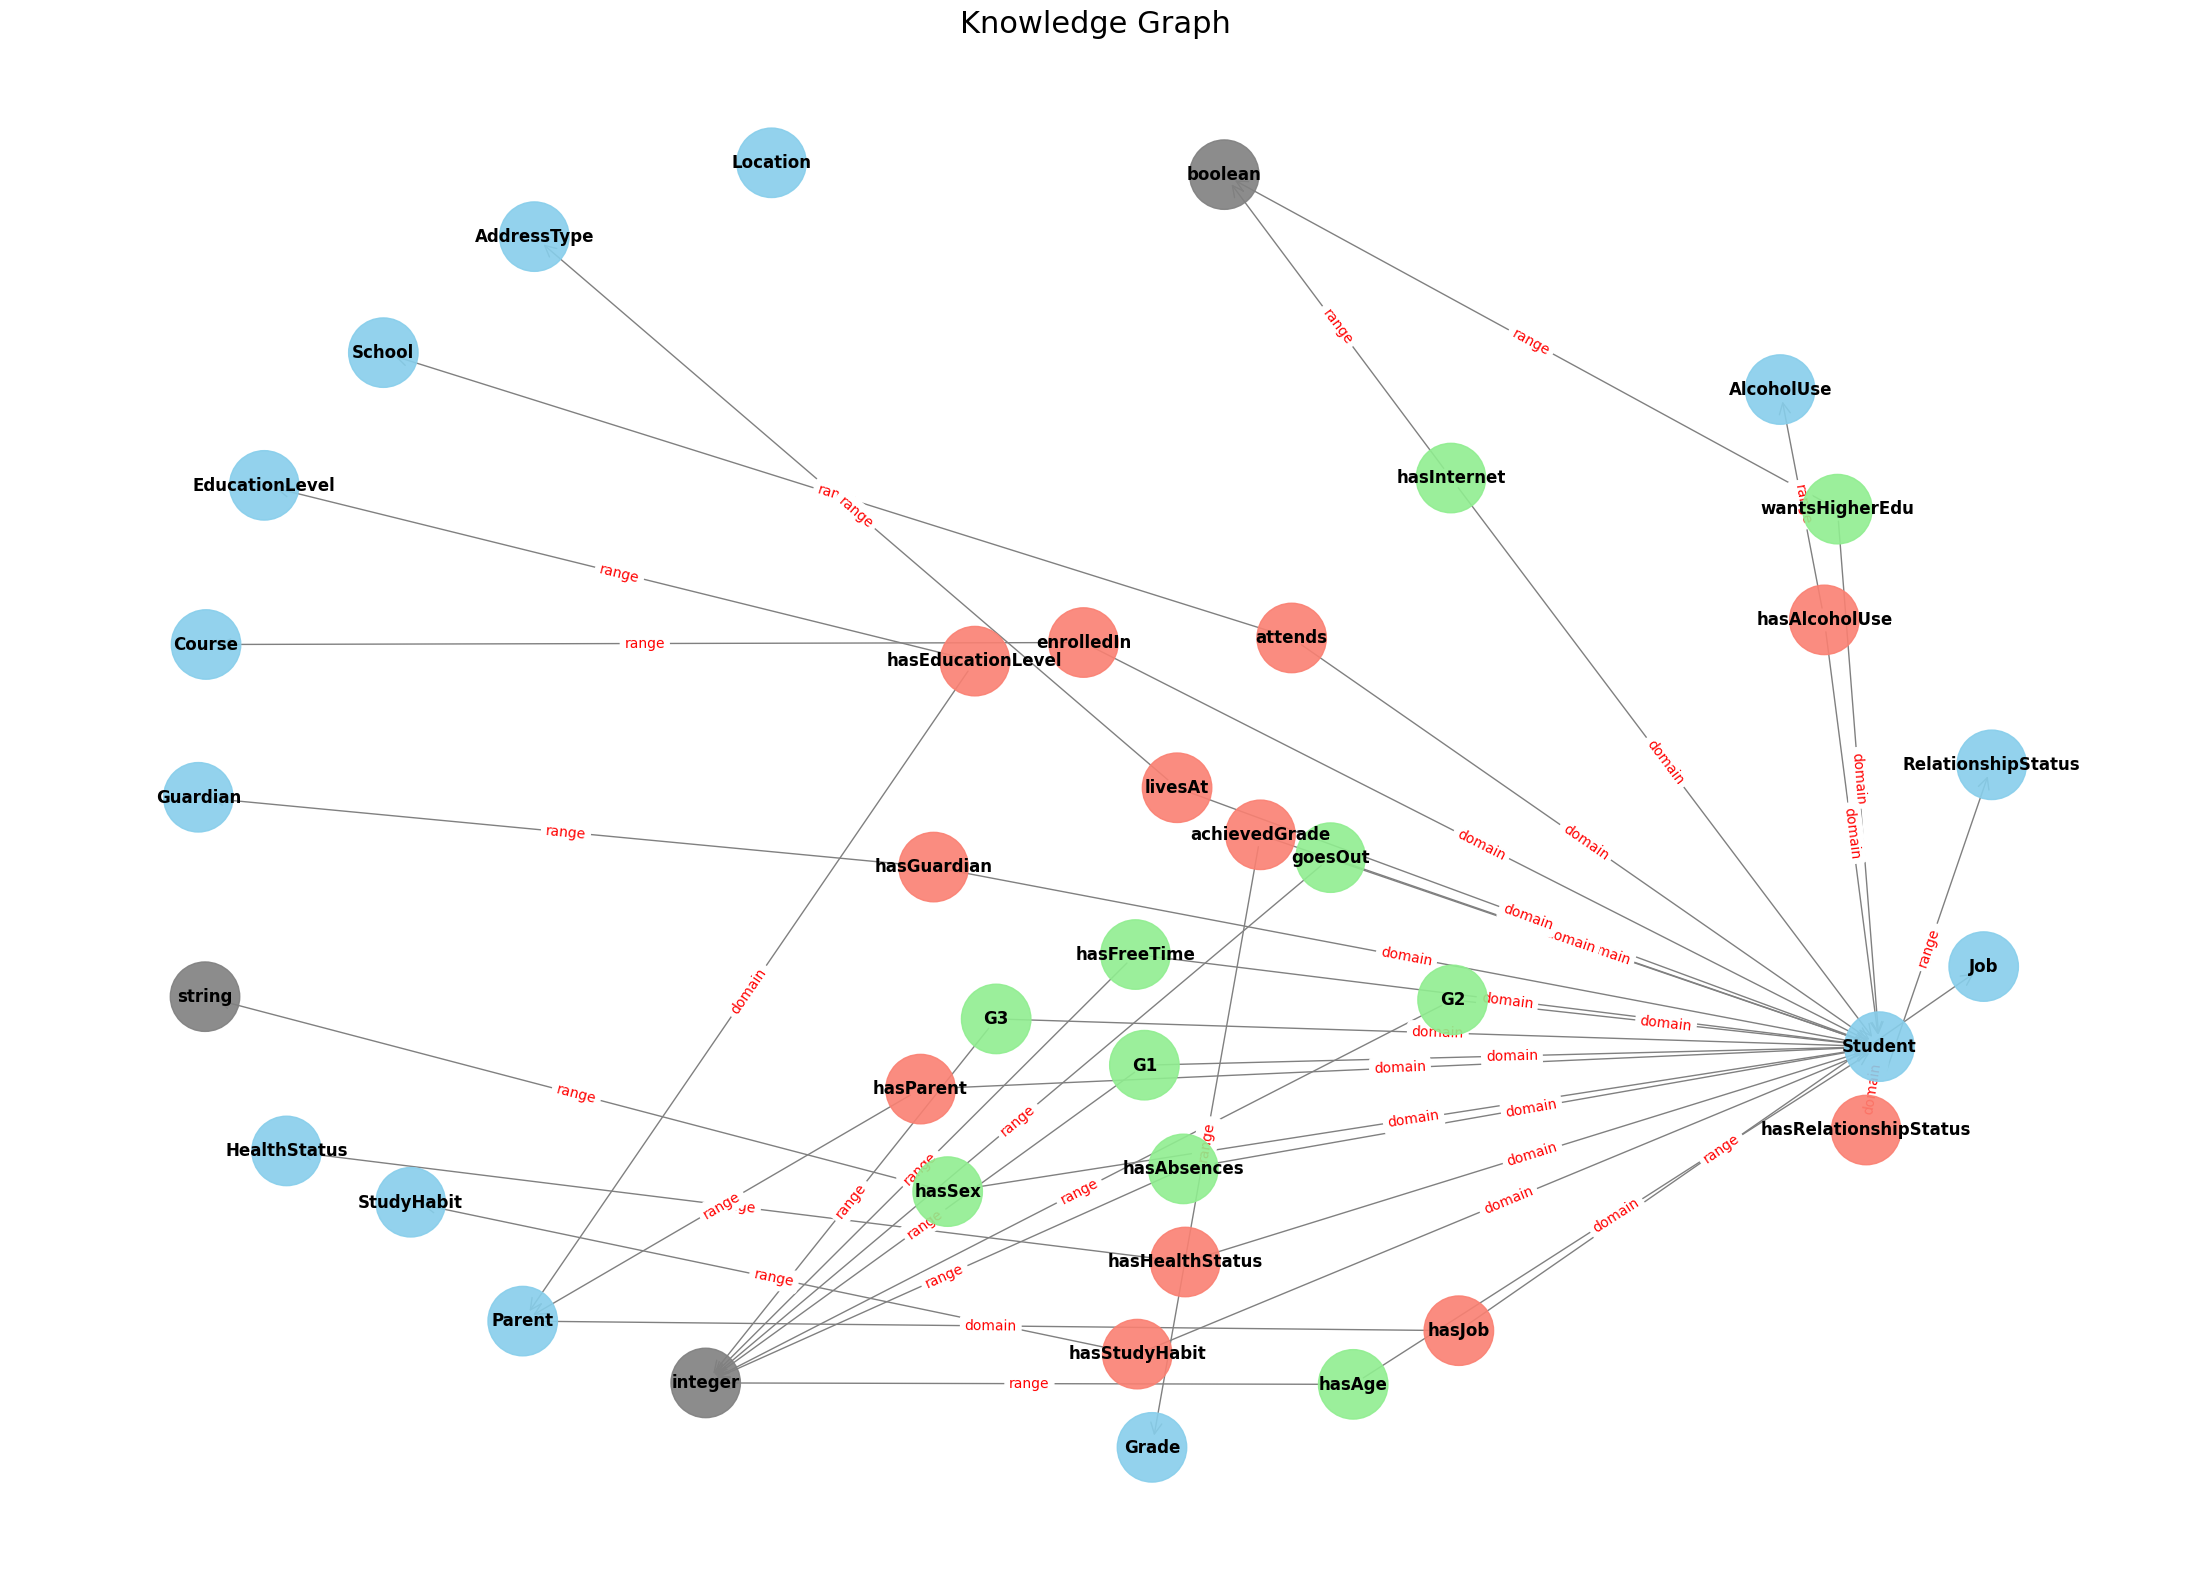

In [ ]:
# Load your ontology
g = Graph()
g.parse("student_performance.owl")
# Create the graph
G = nx.DiGraph()

# Separate nodes by types
classes = set()
data_properties = set()
object_properties = set()

# Identify Classes, Data Properties, and Object Properties
for subj, pred, obj in g:
    if (pred == RDF.type) and (obj in [OWL.Class, RDFS.Class]):
        classes.add(str(subj).split('#')[-1])
    elif (pred == RDF.type) and (obj == OWL.DatatypeProperty):
        data_properties.add(str(subj).split('#')[-1])
    elif (pred == RDF.type) and (obj == OWL.ObjectProperty):
        object_properties.add(str(subj).split('#')[-1])

# Add nodes
for c in classes:
    G.add_node(c, type='class')
for dp in data_properties:
    G.add_node(dp, type='data_property')
for op in object_properties:
    G.add_node(op, type='object_property')

# Add edges: link properties to their domain and range
for s, p, o in g:
    if p == RDFS.domain:
        property_name = str(s).split('#')[-1]
        domain_class = str(o).split('#')[-1]
        G.add_edge(property_name, domain_class, label='domain')
    elif p == RDFS.range:
        property_name = str(s).split('#')[-1]
        range_class = str(o).split('#')[-1]
        G.add_edge(property_name, range_class, label='range')
    elif p == RDFS.subClassOf:
        subclass = str(s).split('#')[-1]
        superclass = str(o).split('#')[-1]
        G.add_edge(subclass, superclass, label='subClassOf')

# Color nodes differently
color_map = []
for node, data in G.nodes(data=True):
    node_type = data.get('type')  # <-- SAFER
    if node_type == 'class':
        color_map.append('skyblue')
    elif node_type == 'data_property':
        color_map.append('lightgreen')
    elif node_type == 'object_property':
        color_map.append('salmon')
    else:
        color_map.append('gray')  # <-- Default color for unknown nodes

# Draw the graph
plt.figure(figsize=(28, 20))
pos = nx.spring_layout(G, k=1.5, iterations=100)  # Better layout

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=2500, alpha=0.9)

# Draw edges with arrows
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray')

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10)

plt.title("Knowledge Graph", fontsize=22)
plt.axis('off')
plt.show()

# **SHACL Validation**

Validate the ontology using SHACL to ensure it conforms to the expected shapes and logical constraints.

In [ ]:
# Load the graph from the serialized OWL file
g = Graph()
g.parse("student_performance.owl", format="xml")

# Use the pyshacl library to validate the graph (which also includes reasoning)
conforms, results_graph, results_text = validate(g)

# Check if the graph conforms to the SHACL shapes and reasoning
if conforms:
    print("-- The graph conforms to the SHACL shapes and reasoning. --")
else:
    print("-- The graph did not conform: --")
    print(results_text)

# You can also save the reasoned graph for further analysis
results_graph.serialize(destination="reasoned_student_performance.owl", format="xml")

-- The graph conforms to the SHACL shapes and reasoning. --


<Graph identifier=N2976ad4da3de4616ac0ff9cbda7823d2 (<class 'rdflib.graph.Graph'>)>

# **SPARQL Queries**

Demonstrate how to query the knowledge graph using SPARQL to extract information about students, their schools, gender, and other attributes.

### **Query 1:** List all students

This query retrieves a list of all students in the ontology.

- `stu:Student` is the class for students.
- The query selects all individuals of type `stu:Student`.
- Only the first 10 students are shown due to the `LIMIT 10`.

In [ ]:
qres = g.query(
    """
    PREFIX stu: <http://www.example.org/student-performance#>
    SELECT ?student
    WHERE {
        ?student a stu:Student .
    }
    LIMIT 10
    """
)

for row in qres:
    print(row.student)

http://www.example.org/student-performance#Student_69
http://www.example.org/student-performance#Student_60
http://www.example.org/student-performance#Student_308
http://www.example.org/student-performance#Student_286
http://www.example.org/student-performance#Student_241
http://www.example.org/student-performance#Student_22
http://www.example.org/student-performance#Student_376
http://www.example.org/student-performance#Student_78
http://www.example.org/student-performance#Student_363
http://www.example.org/student-performance#Student_296


### **Query 2:** List Students and Their Schools

This query retrieves each student and the school they attend.

- `stu:Student` is the class for students.
- `stu:attends` is an object property linking a student to a school.
- The query selects all students and the schools they attend.
- Only the first 10 results are shown.

In [ ]:
qres = g.query(
    """
    PREFIX stu: <http://www.example.org/student-performance#>
    SELECT ?student ?school
    WHERE {
        ?student a stu:Student .
        ?student stu:attends ?school .
    }
    LIMIT 10
    """
)

for row in qres:
    print(f"Student: {row.student}, School: {row.school}")

Student: http://www.example.org/student-performance#Student_69, School: http://www.example.org/student-performance#School_GP
Student: http://www.example.org/student-performance#Student_60, School: http://www.example.org/student-performance#School_GP
Student: http://www.example.org/student-performance#Student_308, School: http://www.example.org/student-performance#School_GP
Student: http://www.example.org/student-performance#Student_286, School: http://www.example.org/student-performance#School_GP
Student: http://www.example.org/student-performance#Student_241, School: http://www.example.org/student-performance#School_GP
Student: http://www.example.org/student-performance#Student_22, School: http://www.example.org/student-performance#School_GP
Student: http://www.example.org/student-performance#Student_376, School: http://www.example.org/student-performance#School_MS
Student: http://www.example.org/student-performance#Student_78, School: http://www.example.org/student-performance#School

### **Query 3:** List All Students and Their Gender

This query retrieves each student and their gender.

- `stu:Student` is the class for students.
- `stu:hasSex` is a data property linking a student to their gender (e.g., Male or Female).
- The query selects all students and their gender.
- Only the first 10 results are shown.

In [ ]:
qres = g.query(
    """
    PREFIX stu: <http://www.example.org/student-performance#>
    SELECT ?student ?gender
    WHERE {
        ?student a stu:Student .
        ?student stu:hasSex ?gender .
    }
    LIMIT 10
    """
)

for row in qres:
    print(f"Student: {row.student}, Gender: {row.gender}")

Student: http://www.example.org/student-performance#Student_69, Gender: http://www.example.org/student-performance#Female
Student: http://www.example.org/student-performance#Student_60, Gender: http://www.example.org/student-performance#Female
Student: http://www.example.org/student-performance#Student_308, Gender: http://www.example.org/student-performance#Male
Student: http://www.example.org/student-performance#Student_286, Gender: http://www.example.org/student-performance#Female
Student: http://www.example.org/student-performance#Student_241, Gender: http://www.example.org/student-performance#Male
Student: http://www.example.org/student-performance#Student_22, Gender: http://www.example.org/student-performance#Male
Student: http://www.example.org/student-performance#Student_376, Gender: http://www.example.org/student-performance#Female
Student: http://www.example.org/student-performance#Student_78, Gender: http://www.example.org/student-performance#Male
Student: http://www.example.

### **Query 4:** Find Students Who Want Higher Education

This query finds students who have indicated they want to pursue higher education.

- `stu:Student` is the class for students.
- `stu:wantsHigherEdu` is a data property indicating if a student wants higher education (boolean).
- The query selects all students where `stu:wantsHigherEdu` is `true`.
- Only the first 10 results are shown.

In [ ]:
qres = g.query(
    """
    PREFIX stu: <http://www.example.org/student-performance#>
    SELECT ?student
    WHERE {
        ?student a stu:Student .
        ?student stu:wantsHigherEdu true .
    }
    LIMIT 10
    """
)

for row in qres:
    print(row.student)

http://www.example.org/student-performance#Student_69
http://www.example.org/student-performance#Student_60
http://www.example.org/student-performance#Student_308
http://www.example.org/student-performance#Student_286
http://www.example.org/student-performance#Student_241
http://www.example.org/student-performance#Student_22
http://www.example.org/student-performance#Student_376
http://www.example.org/student-performance#Student_363
http://www.example.org/student-performance#Student_296
http://www.example.org/student-performance#Student_88


### **Query 5:** Find Students with High Alcohol Consumption During Weekends

This query finds students whose weekend alcohol consumption is high (>= 4).

- `stu:Student` is the class for students.
- `stu:hasAlcoholUse` links a student to an alcohol use individual.
- `stu:weekendUse` is a data property indicating alcohol use during weekends (integer scale).
- The query selects all students whose `stu:weekendUse` is greater than or equal to 4.
- Only the first 10 results are shown.

In [ ]:
qres = g.query(
    """
    PREFIX stu: <http://www.example.org/student-performance#>
    SELECT ?student ?weekendAlcoholUse
    WHERE {
        ?student a stu:Student .
        ?student stu:hasAlcoholUse ?alcoholUse .
        ?alcoholUse stu:weekendUse ?weekendAlcoholUse .
        FILTER(?weekendAlcoholUse >= 4)
    }
    LIMIT 10
    """
)

for row in qres:
    print(f"Student: {row.student}, Weekend Alcohol Use: {row.weekendAlcoholUse}")

Student: http://www.example.org/student-performance#Student_30, Weekend Alcohol Use: 4
Student: http://www.example.org/student-performance#Student_240, Weekend Alcohol Use: 4
Student: http://www.example.org/student-performance#Student_176, Weekend Alcohol Use: 4
Student: http://www.example.org/student-performance#Student_365, Weekend Alcohol Use: 4
Student: http://www.example.org/student-performance#Student_266, Weekend Alcohol Use: 4
Student: http://www.example.org/student-performance#Student_254, Weekend Alcohol Use: 4
Student: http://www.example.org/student-performance#Student_223, Weekend Alcohol Use: 5
Student: http://www.example.org/student-performance#Student_290, Weekend Alcohol Use: 4
Student: http://www.example.org/student-performance#Student_193, Weekend Alcohol Use: 4
Student: http://www.example.org/student-performance#Student_265, Weekend Alcohol Use: 4


### **Query 6:** List All Students and Their Final Grade (G3)

This query retrieves all students and their final grade (G3). And prints the total number of students.

- `stu:Student` is the class for students.
- `stu:achievedGrade` links a student to a grade individual.
- `stu:Grade` is the class for grade individuals.
- The filter ensures only grades for G3 (final grade) are selected.
- `stu:hasGradeValue` gives the numeric value of the grade.

In [ ]:
results = g.query("""
PREFIX stu: <http://www.example.org/student-performance#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT ?student ?g3_grade_value
WHERE {
    ?student rdf:type stu:Student .
    ?student stu:achievedGrade ?grade .
    ?grade rdf:type stu:Grade .
    FILTER (STRSTARTS(STR(?grade), CONCAT(STR(stu:G3_), ""))) .
    ?grade stu:hasGradeValue ?g3_grade_value .
}
""")

count = 0
for row in results:
    print(f"Student: {row.student}, G3: {row.g3_grade_value}")
    count += 1

print(f"\nTotal number of students: {count}")

Student: http://www.example.org/student-performance#Student_199, G3: 10
Student: http://www.example.org/student-performance#Student_145, G3: 11
Student: http://www.example.org/student-performance#Student_383, G3: 0
Student: http://www.example.org/student-performance#Student_372, G3: 11
Student: http://www.example.org/student-performance#Student_120, G3: 15
Student: http://www.example.org/student-performance#Student_182, G3: 17
Student: http://www.example.org/student-performance#Student_171, G3: 16
Student: http://www.example.org/student-performance#Student_333, G3: 0
Student: http://www.example.org/student-performance#Student_353, G3: 8
Student: http://www.example.org/student-performance#Student_321, G3: 9
Student: http://www.example.org/student-performance#Student_277, G3: 9
Student: http://www.example.org/student-performance#Student_147, G3: 11
Student: http://www.example.org/student-performance#Student_221, G3: 0
Student: http://www.example.org/student-performance#Student_13, G3: 11

# Train Knowledge Graph

Demonstrate how to use the knowledge graph for predictive analytics.  
We extract student features and grades from the RDF graph, generate knowledge graph embeddings, and use them (along with tabular features) for regression and classification tasks.

### Steps:
1. Extract triples and student features from the RDF graph.
2. Prepare triples for knowledge graph embedding (PyKEEN).
3. Train a ComplEx embedding model.
4. Build a feature matrix (embeddings + tabular features) and target vector (final grade G3).
5. Train and evaluate regression models to predict final grades (including cross-validation and model comparison).
6. Visualize regression results.
7. Prepare and train a classifier to predict dropout risk.
8. Visualize classification results.

### **Step 1:** Extract Triples and Student Features from the RDF Graph

We extract all triples from the RDF knowledge graph and build a dictionary of student features and their final grades (G3).  
This step prepares the data for embedding and machine learning.

In [ ]:
relevant_features = {
    "G1": XSD.integer,
    "G2": XSD.integer,
    "hasAbsences": XSD.integer,
    "hasFreeTime": XSD.integer,
    "goesOut": XSD.integer,
    "wantsHigherEdu": XSD.boolean,
    "hasInternet": XSD.boolean
}

print("Extracting triples and student features from RDF graph...")
triples = []
student_grades = {}
student_features = {}

def get_int_literal(subject, predicate):
    for _, _, value in g.triples((subject, predicate, None)):
        try:
            return int(str(value))
        except ValueError:
            continue
    return 0

for s, p, o in g.triples((None, RDF.type, STU.Student)):
    student_id = str(s)

    # Extract G3 grade (label only)
    for _, _, grade in g.triples((s, STU.achievedGrade, None)):
        if str(grade).startswith(str(STU.G3_)):
            for _, _, value in g.triples((grade, STU.hasGradeValue, None)):
                student_grades[student_id] = int(value)

    features = {}

    # Extract G1 and G2
    for _, _, grade_node in g.triples((s, STU.achievedGrade, None)):
        grade_node_str = str(grade_node)
        if grade_node_str.startswith(str(STU.G1_)):
            for _, _, val in g.triples((grade_node, STU.hasGradeValue, None)):
                features["G1"] = int(val)
        elif grade_node_str.startswith(str(STU.G2_)):
            for _, _, val in g.triples((grade_node, STU.hasGradeValue, None)):
                features["G2"] = int(val)

    # Other selected features
    for prop, dtype in relevant_features.items():
        if prop in ("G1", "G2"):
            continue
        predicate = getattr(STU, prop)
        for _, _, val in g.triples((s, predicate, None)):
            try:
                if dtype == XSD.integer:
                    features[prop] = int(str(val))
                elif dtype == XSD.boolean:
                    features[prop] = str(val).lower() == 'true'
                else:
                    features[prop] = str(val)
            except Exception as e:
                print(f"Error parsing {prop} for {student_id}: {val} ({e})")

    student_features[student_id] = features

    # Add triples for the extracted features
    for prop, val in features.items():
        predicate = getattr(STU, prop)
        dtype = relevant_features[prop]
        literal_value = Literal(val, datatype=dtype)
        triples.append((s, predicate, literal_value))

Extracting triples and student features from RDF graph...


In [ ]:
# Print features of the first 5 students
print("\nFirst 5 student features:")
for i, (student_id, features) in enumerate(student_features.items()):
    if i >= 5:
        break
    print(f"{student_id}: {features}")


First 5 student features:
http://www.example.org/student-performance#Student_69: {'G1': 16, 'G2': 16, 'hasAbsences': 12, 'hasFreeTime': 4, 'goesOut': 2, 'wantsHigherEdu': True, 'hasInternet': True}
http://www.example.org/student-performance#Student_60: {'G1': 10, 'G2': 11, 'hasAbsences': 6, 'hasFreeTime': 4, 'goesOut': 4, 'wantsHigherEdu': True, 'hasInternet': False}
http://www.example.org/student-performance#Student_308: {'G1': 15, 'G2': 12, 'hasAbsences': 0, 'hasFreeTime': 5, 'goesOut': 3, 'wantsHigherEdu': True, 'hasInternet': False}
http://www.example.org/student-performance#Student_286: {'G1': 18, 'G2': 18, 'hasAbsences': 5, 'hasFreeTime': 3, 'goesOut': 3, 'wantsHigherEdu': True, 'hasInternet': True}
http://www.example.org/student-performance#Student_241: {'G1': 10, 'G2': 11, 'hasAbsences': 2, 'hasFreeTime': 3, 'goesOut': 3, 'wantsHigherEdu': True, 'hasInternet': True}


### **Step 2:** Prepare Triples for Knowledge Graph Embedding

We prepare the extracted triples for use with PyKEEN, which will generate embeddings for all entities in the knowledge graph.

In [ ]:
print("Preparing triples for KG embedding with PyKEEN...")
triples_array = np.array(triples, dtype=str)
triples_factory = TriplesFactory.from_labeled_triples(triples_array)

Preparing triples for KG embedding with PyKEEN...


### **Step 3:** Train ComplEx Embedding Model

After testing several knowledge graph embedding models, we selected `ComplEx` because it achieved the highest score in our prediction task.

We use the model from `PyKEEN` to learn embeddings for all entities in the knowledge graph.
These embeddings will be used as features for machine learning.

In [ ]:
print("Training embedding model (PyKEEN)...")

result = pipeline(
    training=triples_factory,
    testing=triples_factory,
    model='DistMult',
    training_kwargs=dict(num_epochs=100),
)

model = result.model
entity_embeddings = model.entity_representations[0]
embedding_tensor = entity_embeddings(indices=None)
entity_to_id = result.training.entity_to_id
id_to_entity = {v: k for k, v in entity_to_id.items()}

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training embedding model (PyKEEN)...


Training epochs on cuda:0:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/11.0 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/11.0 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/11.0 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/11.0 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/11.0 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/2.77k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.12s seconds


- We train the ComplEx model on the **entire** knowledge graph (using the same **TriplesFactory** for both training and testing) to ensure **every** entity—including all students—gets a learned embedding vector.
- We **do not** rely on PyKEEN’s built-in link-prediction metrics (MRR, Hits@k) for any downstream decisions, so the fact that “testing” uses the same data has **no impact** on our evaluation.

In [ ]:
# Sanity check
# assert all("G3_" not in k for k in entity_to_id.keys()), "G3 info leaked into embeddings!"

if any("G3_" in k for k in entity_to_id.keys()):
    print("Warning: G3 info leaked into embeddings!")
else:
    print("G3 data is clean — no leakage into embeddings.")

G3 data is clean — no leakage into embeddings.


### **Step 4:** Build Feature Matrix and Target Vector

We combine the knowledge graph embeddings with tabular features (G1, G2, studyTime, failures, absences)  
to create the feature matrix `X` and the target vector `y` (final grade G3).

In [ ]:
print("Building dataset with KG embeddings...")

X, y, included_uris = [], [], []

for idx, uri in id_to_entity.items():
    if uri in student_grades:
        feats = student_features.get(uri, {})
        emb = embedding_tensor[idx].detach().cpu().numpy()
        emb_concat = np.hstack([emb.real, emb.imag])

        # Updated feature keys based on your extracted features
        extra_feats = [
            feats.get('G1', 0),
            feats.get('G2', 0),
            feats.get('hasAbsences', 0),
            feats.get('hasFreeTime', 0),
            feats.get('goesOut', 0),
            int(feats.get('wantsHigherEdu', False)),  # Convert boolean to int
            int(feats.get('hasInternet', False))      # Convert boolean to int
        ]

        X.append(np.hstack([emb_concat, extra_feats]))
        y.append(student_grades[uri])
        included_uris.append(uri)

X = np.array(X)
y = np.array(y)
print(f"Final dataset shape: X = {X.shape}, y = {y.shape}")

Building dataset with KG embeddings...
Final dataset shape: X = (395, 107), y = (395,)


### **Step 5:** Regression Model Comparison and Cross-Validation

We compare several regression models (Random Forest, Linear Regression, Decision Tree, Gradient Boosting)  
using 5-fold cross-validation. The results are shown in a table.

In [ ]:
print("Regression: Model Comparison and Cross-Validation")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

scoring = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
    )
    mse    = -np.mean(scores['test_neg_mean_squared_error'])
    mae    = -np.mean(scores['test_neg_mean_absolute_error'])
    r2_val = np.mean(scores['test_r2'])
    results.append({
        'Model': name,
        'MSE': round(mse, 2),
        'MAE': round(mae, 2),
        'R²': round(r2_val, 3),
    })

results_df = pd.DataFrame(results)
print("\nCross-Validated Model Performance:")
print(results_df.to_string(index=False))

Regression: Model Comparison and Cross-Validation

Cross-Validated Model Performance:
            Model  MSE  MAE    R²
    Random Forest 3.64 1.17 0.820
Linear Regression 4.84 1.55 0.761
    Decision Tree 6.96 1.34 0.661
Gradient Boosting 4.10 1.22 0.797


### **Step 6:** Evaluate and Visualize the Best Regression Model

We use one of the best model (Gradient Boosting) on the training set and evaluate it on the test set. Random Forest was also a possible option however, most of the runs shows Gradient Boosting having higher score.

We show the main regression metrics and visualize the results.


Prediction Results (first 20):
Student: http://www.example.org/student-performance#Student_0 | Actual Grade: 14 | Predicted Grade: 14
Student: http://www.example.org/student-performance#Student_100 | Actual Grade: 10 | Predicted Grade: 8
Student: http://www.example.org/student-performance#Student_104 | Actual Grade: 9 | Predicted Grade: 9
Student: http://www.example.org/student-performance#Student_108 | Actual Grade: 0 | Predicted Grade: 1
Student: http://www.example.org/student-performance#Student_111 | Actual Grade: 10 | Predicted Grade: 9
Student: http://www.example.org/student-performance#Student_115 | Actual Grade: 15 | Predicted Grade: 14
Student: http://www.example.org/student-performance#Student_119 | Actual Grade: 0 | Predicted Grade: 1
Student: http://www.example.org/student-performance#Student_122 | Actual Grade: 10 | Predicted Grade: 10
Student: http://www.example.org/student-performance#Student_126 | Actual Grade: 0 | Predicted Grade: 2
Student: http://www.example.org/stu

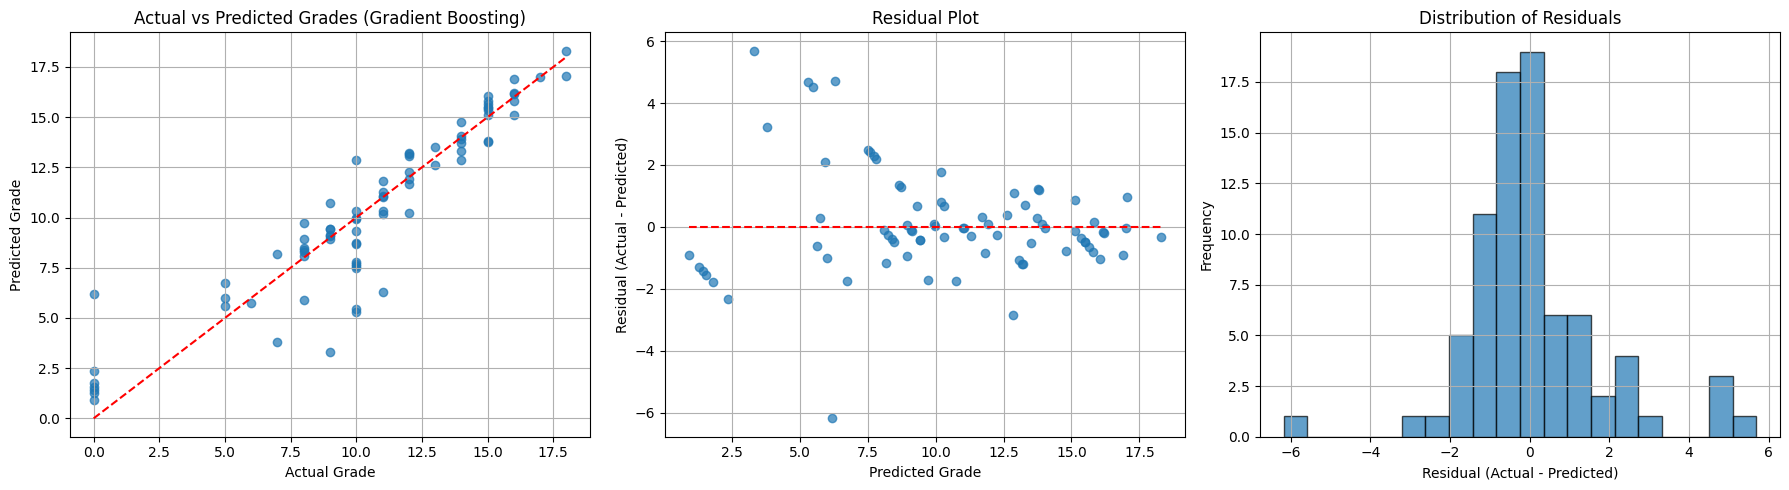


Regression Evaluation Metrics:
MSE: 2.96
MAE: 1.14
R² Score: 0.85


In [ ]:
# Train Gradient Boosting Regressor
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\nPrediction Results (first 20):")
for i in range(min(20, len(y_test))):
    student_uri = included_uris[X_test.shape[0] * i // min(20, len(y_test))]
    actual = y_test[i]
    pred = y_pred[i]
    print(f"Student: {student_uri} | Actual Grade: {actual} | Predicted Grade: {round(pred)}")

print("\nVisualizing regression results...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.7)
axes[0].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
axes[0].set_title("Actual vs Predicted Grades (Gradient Boosting)")
axes[0].set_xlabel("Actual Grade")
axes[0].set_ylabel("Predicted Grade")
axes[0].grid(True)

# 2. Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), colors='r', linestyles='--')
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted Grade")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].grid(True)

# 3. Histogram of Residuals
axes[2].hist(residuals, bins=20, edgecolor='k', alpha=0.7)
axes[2].set_title("Distribution of Residuals")
axes[2].set_xlabel("Residual (Actual - Predicted)")
axes[2].set_ylabel("Frequency")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("\nRegression Evaluation Metrics:")
print("MSE:", round(mean_squared_error(y_test, y_pred), 2))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("R² Score:", round(r2_score(y_test, y_pred), 3))